In [18]:
# Import Libraries
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = "2"  # 0=all logs, 1=filter INFO, 2=filter WARNING, 3=filter ERROR
import numpy as np
import pandas as pd
import cv2
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.optimizers import Adam

In [19]:
# Parameters
IMG_SIZE = 128
DATA_PATH = "../Data/Scores"
BATCH_SIZE = 32
EPOCHS = 20

In [20]:
# Load Dataset
X, y, class_names = [], [], []
class_map = {}

print("[INFO] Loading dataset...")

for shape_name in os.listdir(DATA_PATH):  # e.g., Circle, Square, Triangle
    shape_path = os.path.join(DATA_PATH, shape_name)
    if not os.path.isdir(shape_path):
        continue
    
    for score in os.listdir(shape_path):  # e.g., 0, 1, 2, ...
        score_path = os.path.join(shape_path, score)
        if not os.path.isdir(score_path):
            continue
        
        label = f"{shape_name}_{score}"
        if label not in class_map:
            class_map[label] = len(class_map)
            class_names.append(label)
        
        for file in os.listdir(score_path):
            if file.endswith(".png") or file.endswith(".jpg"):
                path = os.path.join(score_path, file)
                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X.append(img)
                y.append(class_map[label])

X = np.array(X, dtype="float32") / 255.0
X = np.expand_dims(X, -1)   # shape = (N,128,128,1)
y = np.array(y)
y_cat = to_categorical(y, num_classes=len(class_map))

print(f"[INFO] Dataset loaded: {X.shape[0]} samples, {len(class_map)} classes")

[INFO] Loading dataset...
[INFO] Dataset loaded: 4297 samples, 34 classes


In [21]:
# Handle case where some classes have very few samples
min_class_size = min([np.sum(y == i) for i in np.unique(y)])
print(f"[INFO] Minimum samples in any class: {min_class_size}")

[INFO] Minimum samples in any class: 1


In [22]:
# Train-Test Split
print("[INFO] Splitting dataset...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

print(f"[INFO] Train: {X_train.shape}, Test: {X_test.shape}")

[INFO] Splitting dataset...
[INFO] Train: (3437, 128, 128, 1), Test: (860, 128, 128, 1)


In [23]:
print("[INFO] Classes:", class_names)

[INFO] Classes: ['Triangle_0', 'Triangle_4', 'Triangle_5', 'Star_3', 'Star_2', 'Star_0', 'Star_4', 'Star_5', 'Wave_3', 'Wave_2', 'Wave_0', 'Wave_4', 'Circle_3', 'Circle_2', 'Circle_0', 'Circle_4', 'Square_0', 'Square_4', 'Square_5', 'Overlapped pencils_3', 'Overlapped pencils_2', 'Overlapped pencils_0', 'Overlapped pencils_4', 'Overlapped pencils_6', 'Overlapped pencils_5', 'Overlapped circle_2', 'Overlapped circle_0', 'Overlapped circle_4', 'Overlapped circle_6', 'Overlapped circle_5', 'Diagonal_3', 'Diagonal_0', 'Diagonal_4', 'Diagonal_5']


In [24]:
# Build EfficientNetV2 Model
base_model = EfficientNetV2B0(include_top=False, input_shape=(128,128,1), weights=None)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_map), activation="softmax") 
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 4, 4, 1280)     │     5,918,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 34)             │        43,554 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,962,290 (22.74 MB)

 Trainable params: 5,901,682 (22.51 MB)

 Non-trainable params: 60,608 (236.75 KB)

None


In [25]:
# Train model
print("[INFO] Training EfficientNetV2...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

[INFO] Training EfficientNetV2...
Epoch 1/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 129s 995ms/step - accuracy: 0.1039 - loss: 3.0839 - val_accuracy: 0.0945 - val_loss: 2.7858
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 954ms/step - accuracy: 0.1256 - loss: 2.7458 - val_accuracy: 0.1061 - val_loss: 2.7892
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 953ms/step - accuracy: 0.1253 - loss: 2.7191 - val_accuracy: 0.1163 - val_loss: 2.7915
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 85s 984ms/step - accuracy: 0.1219 - loss: 2.7057 - val_accuracy: 0.0901 - val_loss: 2.9810
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 959ms/step - accuracy: 0.1486 - loss: 2.6385 - val_accuracy: 0.1148 - val_loss: 132.8301
Epoch 6/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 952ms/step - accuracy: 0.4115 - loss: 1.9854 - val_accuracy: 0.1061 - val_loss: 34.5579
Epoch 7/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.6163 - loss: 1.3010 - val_accuracy: 0.1134 - val_loss: 45.5417
Epoch 8/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 955ms/step - accura

In [26]:
# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n[RESULT] EfficientNetV2 Test Accuracy: {test_acc:.4f}")


[RESULT] EfficientNetV2 Test Accuracy: 0.1244


In [27]:
# Predict on test data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Print classification report safely
print("\nClassification Report:")
print(classification_report(
    y_true, y_pred_classes,
    labels=np.arange(len(class_map)),
    target_names=class_names,
    zero_division=0
))

27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step

Classification Report:
                      precision    recall  f1-score   support

          Triangle_0       0.00      0.00      0.00         0
          Triangle_4       0.08      0.25      0.12         8
          Triangle_5       0.85      0.34      0.48       119
              Star_3       0.29      0.11      0.15        19
              Star_2       0.00      0.00      0.00         2
              Star_0       0.00      0.00      0.00         3
              Star_4       0.33      0.06      0.10        50
              Star_5       0.00      0.00      0.00        24
              Wave_3       0.20      0.05      0.07        22
              Wave_2       0.00      0.00      0.00         3
              Wave_0       0.00      0.00      0.00         0
              Wave_4       0.80      0.04      0.07       103
            Circle_3       0.07      0.47      0.13        15
            Circle_2       0.00      0.00      0.00         0
    

In [28]:
# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))


Confusion Matrix:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0]
 [  0   2   2   0   0   0   0   0   0   0   0   0   0   0   0   4   0   0
    0   0   0   0   0   0   0   0   0   0   0]
 [  2  21  40   0   0   0   0   0   0   0   0   0   0   0   0  40   0   0
    0   3   0  11   2   0   0   0   0   0   0]
 [  0   0   0   2   4   1   1   0   0   0   0   0   0   0   0   6   0   0
    0   1   0   2   1   0   0   0   0   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0
    0   1   0   0   0   0   0   0   0   0   0]
 [  0   0   1   0   1   0   0   0   0   0   0   0   0   0   0   1   0   0
    0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   1   5   3   3   0   0   0   0   0   0   0   0  19   0   0
    0   8   0   6   3   0   0   0   1   1   0]
 [  0   0   0   2   3   0   5   0   0   0   0   0   0   0   0   5   0   0
    0   7   0   0   1   0   0   0   1   0   0]
 [  1   0   0

In [29]:
# Prediction Helper
def decode_prediction(pred_idx):
    return class_names[pred_idx]

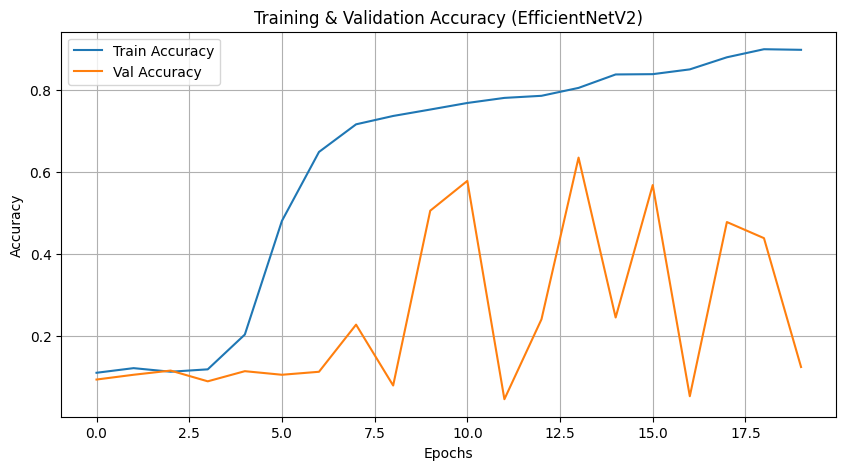

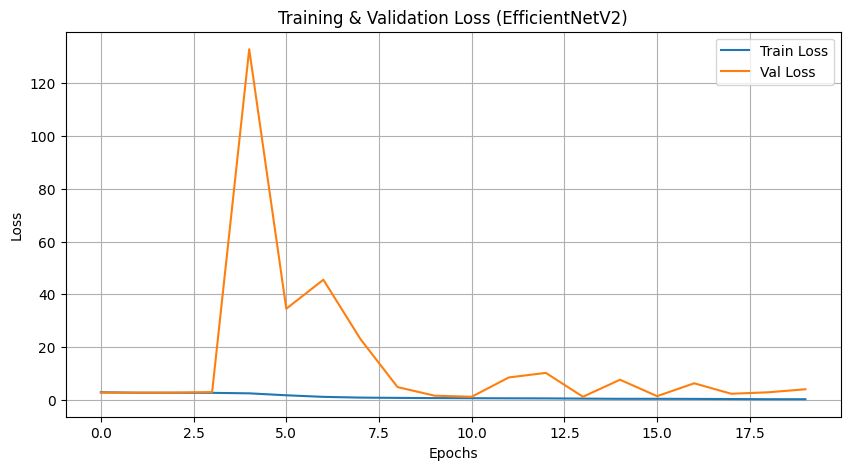

In [30]:
# Plot Accuracy & Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training & Validation Accuracy (EfficientNetV2)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training & Validation Loss (EfficientNetV2)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
# Save Model
SAVE_DIR = "./model_outputs/efficientnetV2"
os.makedirs(SAVE_DIR, exist_ok=True)

In [36]:
# Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy (EfficientNetV2)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "accuracy_plot.png"))
plt.close()

In [37]:
# Save Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss (EfficientNetV2)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "loss_plot.png"))
plt.close()

In [38]:
# Save trained model
model.save(os.path.join(SAVE_DIR, "efficientnetV2_bot2_model.h5"))
print("[INFO] Model saved successfully")

[INFO] Model saved successfully


In [39]:
# Save training history as JSON
with open(os.path.join(SAVE_DIR, "training_history_efficientnetV2.json"), "w") as f:
    json.dump(history.history, f)
print("[INFO] Training history saved as JSON")

[INFO] Training history saved as JSON


In [40]:
# Save
pd.DataFrame(history.history).to_csv(os.path.join(SAVE_DIR, "global_efficientnetV2_training_history.csv"), index=False)

In [42]:
# Convert to DataFrame
report_dict = classification_report(
    y_true, 
    y_pred_classes,
    labels=np.arange(len(class_map)),
    target_names=class_names,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

# Save Classification report
report_path = os.path.join(SAVE_DIR, "efficientnetV2_classification_report.csv")
report_df.to_csv(report_path, index=True)

print("[INFO] Save Classification report as CSV")

[INFO] Save Classification report as CSV
